<a href="https://colab.research.google.com/github/davidtzz/FCD-2026-1/blob/main/sp_4_David_TovarZurita_Jhon_GarciaPareja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

David Felipe Tovar Zurita | Jhon Alejandro García Pareja

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

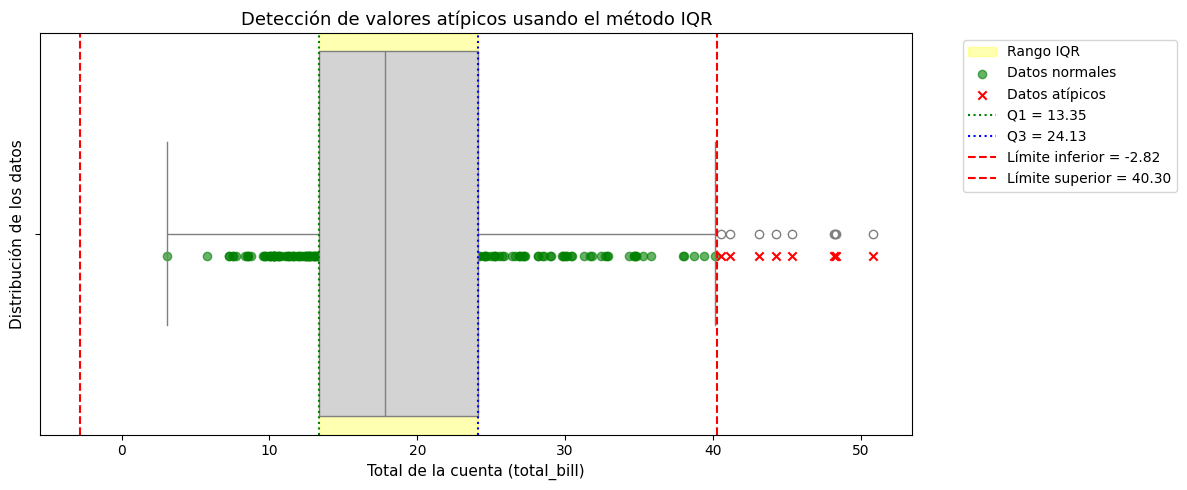

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values

# Cálculo de outliers con IQR
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Separación de datos
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]  # atípicos
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]  # normales

# Gráfica
plt.figure(figsize=(12,5))

# Boxplot base
sns.boxplot(x=total_bill, color="lightgray")

# Rango IQR sombreado
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')

# Puntos normales
plt.scatter(data_b, [0.05]*len(data_b),
            label="Datos normales", alpha=0.6, color='green')

# Puntos atípicos
plt.scatter(data_a, [0.05]*len(data_a),
            label="Datos atípicos", marker='x', color='red')

# Límites y cuartiles
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')

# Etiquetas claras
plt.xlabel("Total de la cuenta (total_bill)", fontsize=11)
plt.ylabel("Distribución de los datos", fontsize=11)
plt.title("Detección de valores atípicos usando el método IQR", fontsize=13)

# Leyenda organizada
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##**ANÁLISIS**

1. Los valores atípicos se identifican como aquellos que están fuera de los límites definidos por 1.5 * IQR.
2. Se identifican algunos valores por encima del límite superior, los cuales se consideran atípicos según el criterio de 1.5 * IQR.
3. No se observan muchos valores por debajo del límite inferior, indicando que los atípicos están principalmente en cuentas altas.
4. Los valores atípicos se separan claramente del resto de la distribución.
5. Esto sugiere que existen cuentas significativamente más altas que el promedio, pero no afectan la mayoría de los datos.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

##**Análisis Variable TIP**

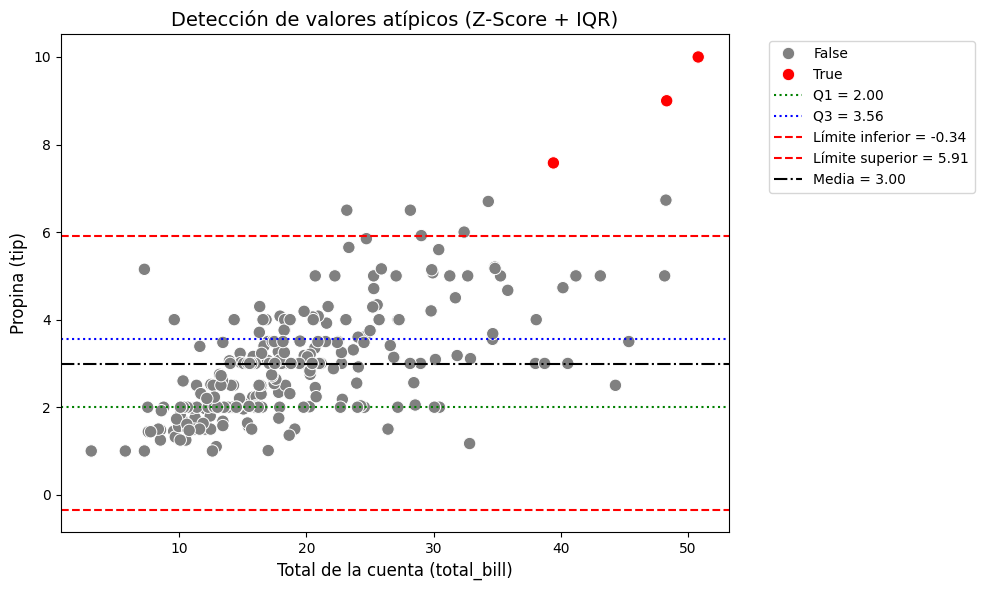

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# Cargar datos
tips = sns.load_dataset("tips")

# Crear DataFrame de trabajo
df = tips[['total_bill', 'tip']].copy()

# ======================
# Z-SCORE
# ======================
df['z_score'] = zscore(df['tip'])
df['outlier_z'] = df['z_score'].abs() > 3  # True / False

# ======================
# IQR (sobre tip)
# ======================
Q1 = df['tip'].quantile(0.25)
Q3 = df['tip'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# ======================
# GRÁFICA
# ======================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='outlier_z',  # True / False
    palette={False: 'gray', True: 'red'},
    s=80
)

# Líneas IQR
plt.axhline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axhline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axhline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axhline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')

# Media (Z-score)
plt.axhline(df['tip'].mean(), color='black', linestyle='-.', label=f'Media = {df["tip"].mean():.2f}')

# Etiquetas
plt.xlabel("Total de la cuenta (total_bill)", fontsize=12)
plt.ylabel("Propina (tip)", fontsize=12)
plt.title("Detección de valores atípicos (Z-Score + IQR)", fontsize=14)

# Leyenda organizada
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##**Análisis Variable TOTAL BILL**

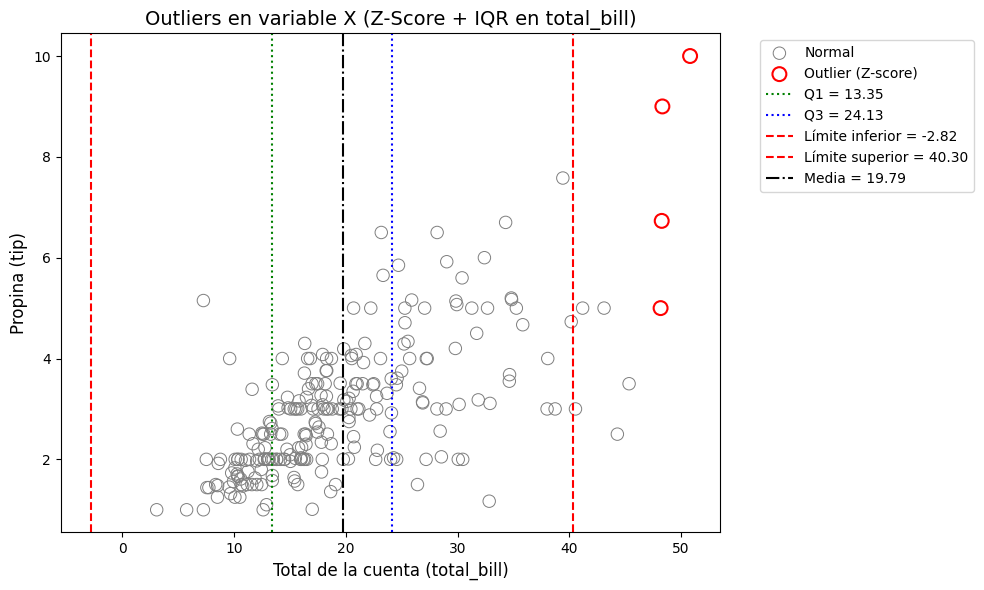

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# Cargar datos
tips = sns.load_dataset("tips")

# Crear DataFrame de trabajo
df = tips[['total_bill', 'tip']].copy()

# ======================
# Z-SCORE (sobre X = total_bill)
# ======================
df['z_score_x'] = zscore(df['total_bill'])
df['outlier_z_x'] = df['z_score_x'].abs() > 3  # True / False

# ======================
# IQR (sobre total_bill)
# ======================
Q1_x = df['total_bill'].quantile(0.25)
Q3_x = df['total_bill'].quantile(0.75)
IQR_x = Q3_x - Q1_x

lim_inf_x = Q1_x - 1.5 * IQR_x
lim_sup_x = Q3_x + 1.5 * IQR_x

# ======================
# GRÁFICA
# ======================
plt.figure(figsize=(10,6))

# Puntos normales (sin relleno)
sns.scatterplot(
    data=df[~df['outlier_z_x']],
    x='total_bill',
    y='tip',
    facecolors='none',
    edgecolor='gray',
    s=80,
    label='Normal'
)

# Puntos outliers
sns.scatterplot(
    data=df[df['outlier_z_x']],
    x='total_bill',
    y='tip',
    facecolors='none',
    edgecolor='red',
    s=100,
    linewidth=1.5,
    label='Outlier (Z-score)'
)

# ======================
# Líneas verticales (IQR en X)
# ======================
plt.axvline(Q1_x, color='green', linestyle=':', label=f'Q1 = {Q1_x:.2f}')
plt.axvline(Q3_x, color='blue', linestyle=':', label=f'Q3 = {Q3_x:.2f}')
plt.axvline(lim_inf_x, color='red', linestyle='--', label=f'Límite inferior = {lim_inf_x:.2f}')
plt.axvline(lim_sup_x, color='red', linestyle='--', label=f'Límite superior = {lim_sup_x:.2f}')

# Media en X
plt.axvline(df['total_bill'].mean(), color='black', linestyle='-.', label=f'Media = {df["total_bill"].mean():.2f}')

# ======================
# Líneas horizontales (tip)
# ======================

# Etiquetas
plt.xlabel("Total de la cuenta (total_bill)", fontsize=12)
plt.ylabel("Propina (tip)", fontsize=12)
plt.title("Outliers en variable X (Z-Score + IQR en total_bill)", fontsize=14)

# Leyenda
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##**Análisis COMBINADO**

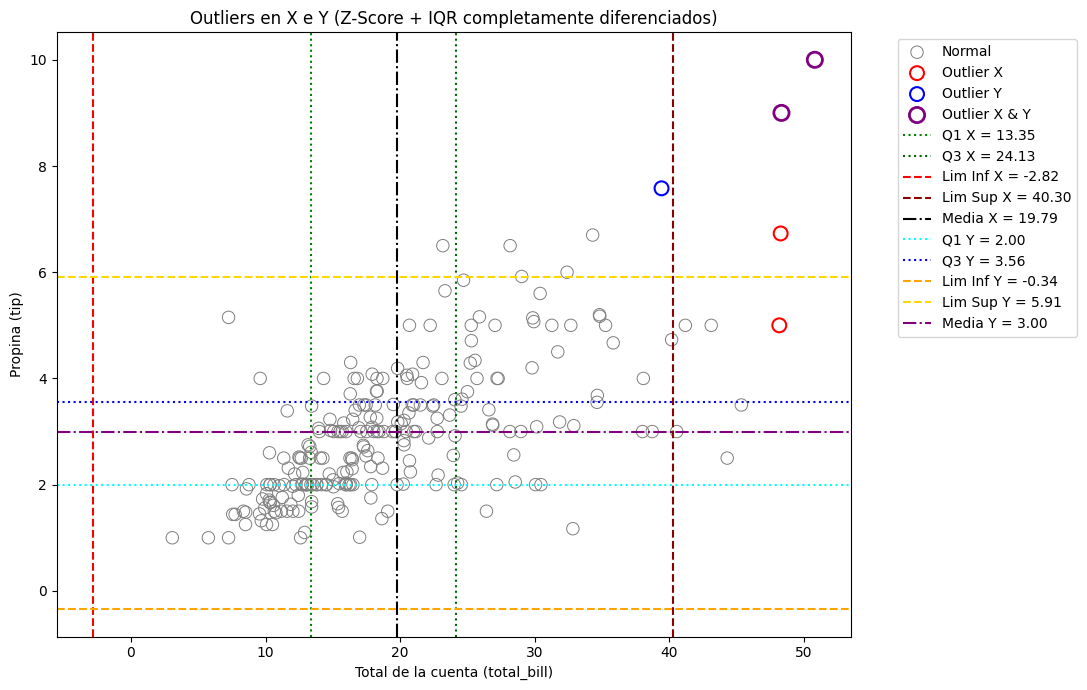

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# Cargar datos
tips = sns.load_dataset("tips")

# DataFrame
df = tips[['total_bill', 'tip']].copy()

# ======================
# Z-SCORE (X y Y)
# ======================
df['z_x'] = zscore(df['total_bill'])
df['z_y'] = zscore(df['tip'])

df['outlier_x'] = df['z_x'].abs() > 3
df['outlier_y'] = df['z_y'].abs() > 3

# ======================
# IQR X (total_bill)
# ======================
Q1_x = df['total_bill'].quantile(0.25)
Q3_x = df['total_bill'].quantile(0.75)
IQR_x = Q3_x - Q1_x

lim_inf_x = Q1_x - 1.5 * IQR_x
lim_sup_x = Q3_x + 1.5 * IQR_x

# ======================
# IQR Y (tip)
# ======================
Q1_y = df['tip'].quantile(0.25)
Q3_y = df['tip'].quantile(0.75)
IQR_y = Q3_y - Q1_y

lim_inf_y = Q1_y - 1.5 * IQR_y
lim_sup_y = Q3_y + 1.5 * IQR_y

# ======================
# GRÁFICA
# ======================
plt.figure(figsize=(11,7))

# Puntos
sns.scatterplot(
    data=df[~df['outlier_x'] & ~df['outlier_y']],
    x='total_bill',
    y='tip',
    facecolors='none',
    edgecolor='gray',
    s=80,
    label='Normal'
)

sns.scatterplot(
    data=df[df['outlier_x'] & ~df['outlier_y']],
    x='total_bill',
    y='tip',
    facecolors='none',
    edgecolor='red',
    s=100,
    linewidth=1.5,
    label='Outlier X'
)

sns.scatterplot(
    data=df[~df['outlier_x'] & df['outlier_y']],
    x='total_bill',
    y='tip',
    facecolors='none',
    edgecolor='blue',
    s=100,
    linewidth=1.5,
    label='Outlier Y'
)

sns.scatterplot(
    data=df[df['outlier_x'] & df['outlier_y']],
    x='total_bill',
    y='tip',
    facecolors='none',
    edgecolor='purple',
    s=120,
    linewidth=2,
    label='Outlier X & Y'
)

# ======================
# X (verticales)
# ======================
plt.axvline(Q1_x, color='green', linestyle=':', label=f'Q1 X = {Q1_x:.2f}')
plt.axvline(Q3_x, color='darkgreen', linestyle=':', label=f'Q3 X = {Q3_x:.2f}')
plt.axvline(lim_inf_x, color='red', linestyle='--', label=f'Lim Inf X = {lim_inf_x:.2f}')
plt.axvline(lim_sup_x, color='darkred', linestyle='--', label=f'Lim Sup X = {lim_sup_x:.2f}')
plt.axvline(df['total_bill'].mean(), color='black', linestyle='-.', label=f'Media X = {df["total_bill"].mean():.2f}')

# ======================
# Y (horizontales)
# ======================
plt.axhline(Q1_y, color='cyan', linestyle=':', label=f'Q1 Y = {Q1_y:.2f}')
plt.axhline(Q3_y, color='blue', linestyle=':', label=f'Q3 Y = {Q3_y:.2f}')
plt.axhline(lim_inf_y, color='orange', linestyle='--', label=f'Lim Inf Y = {lim_inf_y:.2f}')
plt.axhline(lim_sup_y, color='gold', linestyle='--', label=f'Lim Sup Y = {lim_sup_y:.2f}')
plt.axhline(df['tip'].mean(), color='purple', linestyle='-.', label=f'Media Y = {df["tip"].mean():.2f}')

# Etiquetas
plt.xlabel("Total de la cuenta (total_bill)")
plt.ylabel("Propina (tip)")
plt.title("Outliers en X e Y (Z-Score + IQR completamente diferenciados)")

# Leyenda
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##**ANÁLISIS**

1. La mayoría de los datos se concentran en una relación creciente entre total de la cuenta y propina.
2. Se identifican algunos valores atípicos en la variable total_bill (X), donde las cuentas son más altas de lo habitual.
3. También aparecen pocos atípicos en tip (Y), indicando propinas fuera del comportamiento general.
4. Los outliers se ubican fuera de los límites definidos por IQR y también presentan valores extremos según Z-score.
5. La mayoría de los puntos se mantienen dentro de los rangos normales, mostrando con sistencia en los datos.
6. Existen algunos valores atípicos que coinciden en ambas variables (X y Y), alejándose simultáneamente del comportamiento normal.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

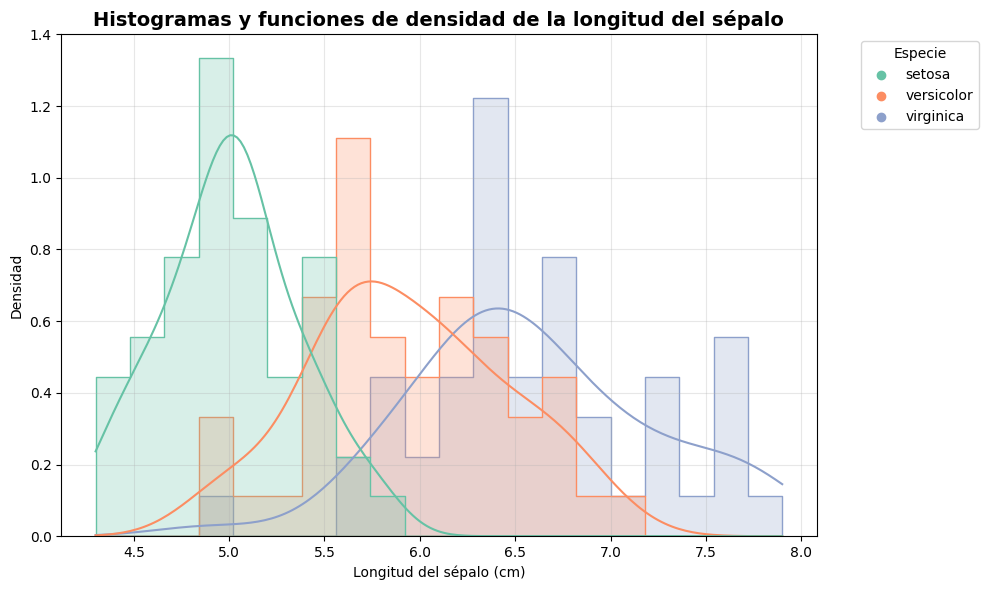

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
iris = sns.load_dataset("iris")

# Crear figura
plt.figure(figsize=(10, 6))

# Histograma con KDE separado por especie
ax = sns.histplot(
    data=iris,
    x="sepal_length",
    hue="species",
    kde=True,
    bins=20,
    element="step",
    stat="density",
    common_norm=False,
    palette="Set2",
    legend=False
)

# Título y ejes
plt.title("Histogramas y funciones de densidad de la longitud del sépalo", fontsize=14, weight="bold")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Densidad")

# Crear leyenda manual
species = iris["species"].unique()
palette = sns.color_palette("Set2", len(species))

for i, sp in enumerate(species):
    ax.scatter([], [], color=palette[i], label=sp)

ax.legend(title="Especie", bbox_to_anchor=(1.05, 1), loc="upper left")

# Grid y ajuste
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##**ANÁLISIS**
1. La gráfica muestra tres histogramas separados porque los datos están diferenciados por la variable species.
2. Cada especie presenta su propia distribución de la longitud del sépalo, lo que permite comparar sus comportamientos.
3. Se observa que los datos de cada especie se concentran en rangos distintos, generando separaciones entre las distribuciones.
4. En los extremos de cada histograma aparecen valores alejados del resto de su grupo, los cuales pueden considerarse atípicos dentro de cada especie.
5. La identificación de estos valores se basa en su baja frecuencia y su ubicación en las colas de cada distribución.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

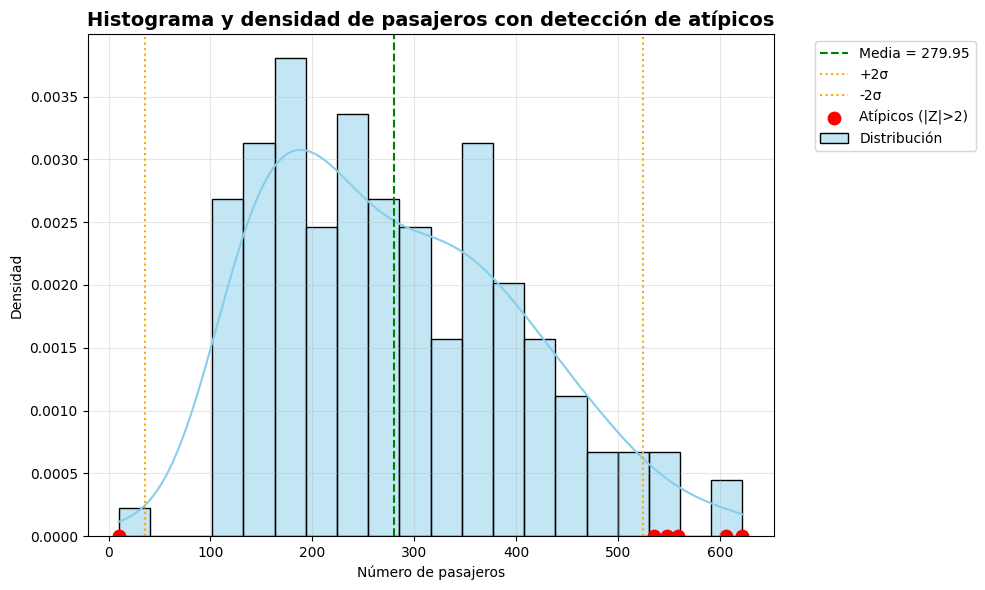

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# Cargar datos
flights = sns.load_dataset("flights")
x = flights["passengers"].values

# Agregar valores atípicos
x = np.append(x, [10, 500])

# Calcular Z-score
z_scores = zscore(x)
outliers = x[np.abs(z_scores) > 2]

# Crear figura
plt.figure(figsize=(10, 6))

# Histograma
ax = sns.histplot(
    x=x,
    bins=20,
    kde=True,
    color="skyblue",
    stat="density",
    label="Distribución"
)

# Media y límites
media = np.mean(x)
std = np.std(x)

ax.axvline(media, color="green", linestyle="--", label=f"Media = {media:.2f}")
ax.axvline(media + 2*std, color="orange", linestyle=":", label="+2σ")
ax.axvline(media - 2*std, color="orange", linestyle=":", label="-2σ")

ax.scatter(outliers, np.zeros_like(outliers),
           color="red", s=80, label="Atípicos (|Z|>2)")

# Título y ejes
plt.title("Histograma y densidad de pasajeros con detección de atípicos", fontsize=14, weight="bold")
plt.xlabel("Número de pasajeros")
plt.ylabel("Densidad")

# Leyenda
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Grid suave
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##**ANÁLISIS**
1. La mayor concentración de datos, representada por el pico de la curva, no coincide exactamente con la media.
2. Esto indica que la distribución no es completamente simétrica y puede estar sesgada.
3. Los valores atípicos se identifican fuera del rango de ±2 desviaciones estándar, alejados del comportamiento principal.
4. Estos puntos se ubican en las colas de la distribución, donde la densidad es baja.
4. La diferencia entre el pico de la curva y la media sugiere que los datos no están centrados de manera uniforme.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

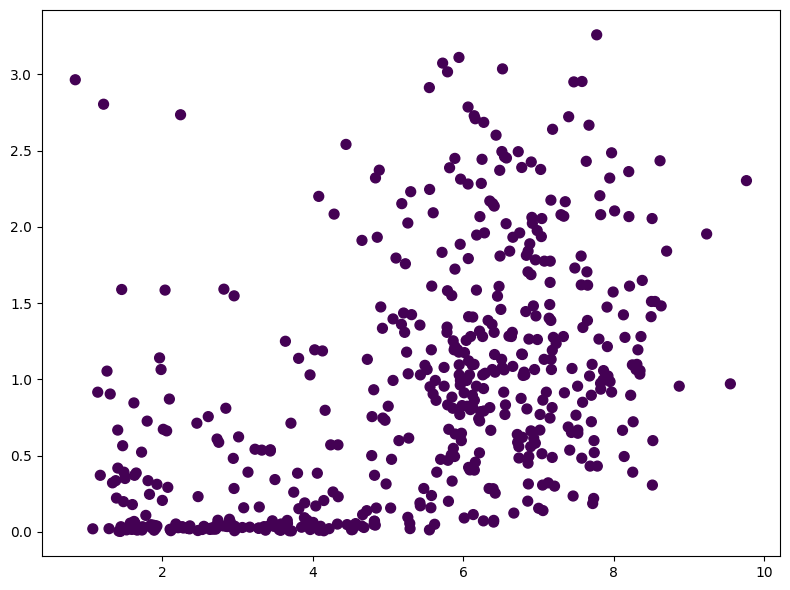

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
